# The power stage

Dead time off the silicon, a counted hold, the six gates in one snapshot, a burst, the switching arithmetic.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The dead time, read from the silicon

`check()` re-reads BDTR DTG every time; DTG 0 refuses (the 2EDL8034 has no interlock). 4.21 ns a count. `.ioc` DTG 19 = 79 ns; the record's DTG 8 = 33.7 ns (7 counts tripped the supply's OCP, 2026-08-29).

In [3]:
stage = device.gates
dead = stage.dead_time()
check = stage.check()
print('dead time  :', dead)
print('check      :', {k: check[k] for k in ('deadtime', 'deadtime_ns', 'deadtime_floor',
                                            'period', 'gate_shorts', 'pwm_enabled', 'fault')})
DTS_NS = 1e3 / 237.5                       # one DTG count at 237.5 MHz
print()
print('  DTG      ns   which')
for counts, which in ((check['deadtime_floor'], 'the firmware floor, 20 ns rounded up'),
                      (7, 'tripped the supply OCP, 2026-08-29'),
                      (8, "the record's 30 ns, rounded up"),
                      (19, "the .ioc, until the record loads"),
                      (127, 'the ceiling of the register')):
    print('  %3d   %5.1f   %s' % (counts, counts * DTS_NS, which))
print()
print('the stage reads DTG %d = %d ns, %.1fx the record\'s 33.7 ns'
      % (check['deadtime'], check['deadtime_ns'], check['deadtime_ns'] / 33.7))

dead time  : {'nanoseconds': 79, 'skew': 0, 'floor': 5}
check      : {'deadtime': 19, 'deadtime_ns': 79, 'deadtime_floor': 5, 'period': 2376, 'gate_shorts': (), 'pwm_enabled': False, 'fault': True}

  DTG      ns   which
    5    21.1   the firmware floor, 20 ns rounded up
    7    29.5   tripped the supply OCP, 2026-08-29
    8    33.7   the record's 30 ns, rounded up
   19    80.0   the .ioc, until the record loads
  127   534.7   the ceiling of the register

the stage reads DTG 19 = 79 ns, 2.3x the record's 33.7 ns


## 3 Arming, and what refuses first

Three refusals before the FETs: MOE (`on()` sets it), the interlock (Cinj and Clevel want 3 V; the bench board reads 0.77 and 0.06 V, the stand-in 0.97 and 0.04: `ignore_interlock=True`), the break on PE15 (`bypass_sto=True`).

In [4]:
import textwrap

from coaxial.errors import RigError

daq = device.daq
daq.enable()
for name, volts, ok, want in stage.interlock():
    print('%-8s %-8s ok=%-5s want=%s' % (name, '-' if volts is None else '%.2f V' % volts, ok, want))
gd = device.gate_drivers
refused = []
for what, call in (('a duty before arm', lambda: gd.write((10, 0, 0))),
                   ('on() under the interlock', lambda: stage.on()),
                   ('on() past the interlock, break latched',
                    lambda: stage.on(ignore_interlock=True))):
    try:
        call()
        print('%-42s took' % what)
    except RigError as e:
        refused.append(what)
        print(textwrap.fill('%s REFUSED: %s' % (what, e), width=96,
                            subsequent_indent='    '))
armed = stage.on(bypass_sto=True, ignore_interlock=True)
print()
print('armed: pwm_enabled %s  fault %s  break_bypassed %s  duty %s'
      % (armed['pwm_enabled'], armed['fault'], armed['break_bypassed'], armed['duty']))

AFE_ON   -        ok=True  want=None
Cinj     0.75 V   ok=False want=3.0
Clevel   0.06 V   ok=False want=3.0
a duty before arm REFUSED: the gate drivers are not enabled (simulated)
on() under the interlock REFUSED: the arming interlock is not satisfied: Cinj 0.74 V, wants 3.0,
    Clevel 0.06 V, wants 3.0. The schematic wants the charge pump up and the level detector
    tripped before the gate drive is armed. Pass ignore_interlock=True to arm anyway, which is
    what an unmodified bench board needs
on() past the interlock, break latched REFUSED: the board refused to enable the gate drivers -
    check fault, and whether the STO chain has released (simulated)

armed: pwm_enabled True  fault False  break_bypassed True  duty (0, 0, 0)


## 4 A counted hold

A compare write lands in ~15 ms (750 periods): op 2 counts periods instead. 500 = 10.000 ms at 50 kHz; link-timed, 100 ms measured 93-108 ms (FINDINGS).

In [5]:
import time

period = armed['period']
tenth = (period - 1) // 10
gd.write((tenth, 0, 0), periods=500)
snap = gd.state()
for key in ('period', 'deadtime', 'deadtime_ns', 'duty', 'requested_ticks', 'pins',
            'pins_at', 'periods_left', 'updates', 'overruns', 'keepalive',
            'worst_gap_cycles', 'gate_shorts', 'break_bypassed', 'dcbus_raw', 'ntc_raw'):
    print('%-16s %s' % (key, snap.get(key, 'not in this reply')))
time.sleep(0.05)
after = gd.state()
print()
print('asked %d of %d ticks = %.1f %% for 500 periods = %.3f ms'
      % (tenth, period - 1, 100.0 * tenth / (period - 1), 500.0 / 50e3 * 1e3))
print('periods_left straight after the write %d, 50 ms later %d; duty now %s'
      % (snap['periods_left'], after['periods_left'], after['duty']))

period           2376
deadtime         19
deadtime_ns      79
duty             (237, 0, 0)
requested_ticks  (237.0, 0.0, 0.0)
pins             {'UL': True, 'UH': False, 'VL': True, 'VH': False, 'WL': True, 'WH': False}
pins_at          1943
periods_left     498
updates          0
overruns         0
keepalive        1498000
worst_gap_cycles 24700
gate_shorts      ()
break_bypassed   True
dcbus_raw        not in this reply
ntc_raw          not in this reply

asked 237 of 2375 ticks = 10.0 % for 500 periods = 10.000 ms
periods_left straight after the write 498, 50 ms later 0; duty now (0, 0, 0)


## 5 The six gates in one snapshot

`pins`: one IDR load with TIM1->CNT as `pins_at` - never a leg with both FETs on. `gate_shorts` drives one pin and watches its neighbour; no legs while armed.

In [6]:
gd.write((tenth, tenth, tenth))
snapshots = [gd.state() for _ in range(12)]
print('  CNT   UL UH   VL VH   WL WH   both on?')
for s in snapshots:
    p = s['pins']
    both = [leg for leg in ('U', 'V', 'W') if p[leg + 'L'] and p[leg + 'H']]
    print('%5d %5d%3d%5d%3d%5d%3d   %s'
          % (s['pins_at'], p['UL'], p['UH'], p['VL'], p['VH'], p['WL'], p['WH'],
             ','.join(both) if both else 'no'))
walked = sorted(s['pins_at'] for s in snapshots)
both_on = sum(1 for s in snapshots for leg in ('U', 'V', 'W')
              if s['pins'][leg + 'L'] and s['pins'][leg + 'H'])
high = sum(1 for s in snapshots for leg in ('U', 'V', 'W') if s['pins'][leg + 'H'])
print()
print('%d reads, CNT %d to %d of %d; high side on in %d of %d leg samples (%.1f %% asked); '
      'both FETs on in %d' % (len(snapshots), walked[0], walked[-1], snap['period'],
                              high, 3 * len(snapshots), 100.0 * tenth / (period - 1), both_on))

  CNT   UL UH   VL VH   WL WH   both on?
  801     1  0    1  0    1  0   no
 1418     1  0    1  0    1  0   no
 2035     1  0    1  0    1  0   no
  276     1  0    1  0    1  0   no
  893     1  0    1  0    1  0   no
 1510     1  0    1  0    1  0   no
 2127     1  0    1  0    1  0   no
  368     1  0    1  0    1  0   no
  985     1  0    1  0    1  0   no
 1602     1  0    1  0    1  0   no
 2219     1  0    1  0    1  0   no
  460     1  0    1  0    1  0   no

12 reads, CNT 276 to 2219 of 2376; high side on in 0 of 36 leg samples (10.0 % asked); both FETs on in 0


## 6 A burst over the currents

A capture decimates nothing: every sweep a record until the ring is full; `dropped` 0. Tared with three equal duties: no phase current (2026-08-27).

tare: {'Phase U': 1382, 'Phase V': -8006, 'Phase W': 358}


300 records, dropped 0, 0.704 s of window; dt 47 us to 2524 us; the ring holds 16990
Phase U (A)  mean +0.099 A  rms 0.210 A
Phase V (A)  mean -0.172 A  rms 0.224 A
Phase W (A)  mean +0.010 A  rms 0.219 A
measured floor on the board, A rms: (0.35, 0.41)
gate columns, mean duty: PWMUL 0.000  PWMUH 0.000  PWMVL 0.000  PWMVH 0.000  PWMWL 0.000  PWMWH 0.000


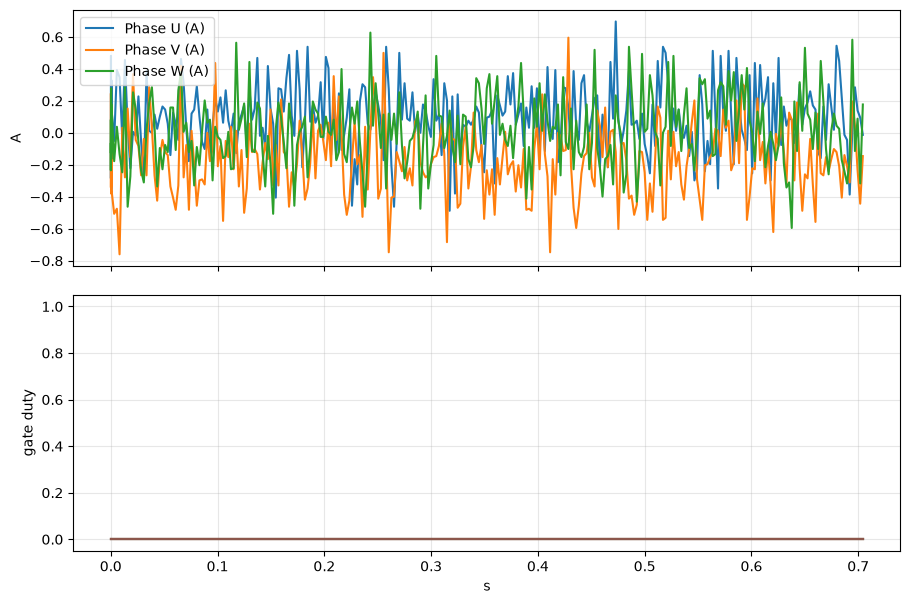

In [7]:
from coaxial.model import inverter
from coaxial.draw.figures import figure, show

device.set_time_from_pc()
print('tare:', device.calibration.tare('phaseU', 'phaseV', 'phaseW'))
burst = daq.capture('phaseU', 'phaseV', 'phaseW', records=300)
shape = daq.state()
df = daq.frame(burst, index='elapsed', scaled=True)
amps = [c for c in df.columns if c.endswith('(A)')]
gates = [c for c in df.columns if c.startswith('TIM1_CH')]
spans = [r.dt for r in burst if r.dt]
print('%d records, dropped %d, %.3f s of window; dt %.0f us to %.0f us; the ring holds %d'
      % (len(burst), shape['dropped'], df.index[-1], min(spans) * 1e6, max(spans) * 1e6,
         shape['capacity']))
noise = df[amps].std()
for column in amps:
    print('%-12s mean %+.3f A  rms %.3f A' % (column, df[column].mean(), noise[column]))
print('measured floor on the board, A rms: %s' % (inverter.NOISE_A,))
print('gate columns, mean duty:',
      '  '.join('%s %.3f' % (c.split('/')[1], df[c].mean()) for c in gates))
fig, (top, bottom) = figure(rows=2, sharex=True)
for column in amps:
    top.plot(df.index, df[column], label=column)
top.set_ylabel('A')
top.legend(loc='upper left')
for column in gates:
    bottom.plot(df.index, df[column])
bottom.set_ylabel('gate duty')
bottom.set_ylim(-0.05, 1.05)
bottom.set_xlabel('s')
show(fig)

The stand-in's gate fields follow the drive's modulation, not a raw compare: zero here.

In [8]:
gd.write((0, 0, 0))
released = stage.off()
print('pwm_enabled', released['pwm_enabled'], ' break_bypassed', released['break_bypassed'],
      ' duty', released['duty'])

pwm_enabled False  break_bypassed False  duty (0, 0, 0)


## 7 What switching costs: the constants

`coaxial.model.inverter`: FSW, dead time, the FET's junction law (VDMOS model, `half_bridge.asc`), L_LOOP, the shunt. RDS_ON 1.8 mohm typical (2.1 max).

In [9]:
print('FSW %.0f Hz  TS %.1f us  T_DEAD %.1f ns (DTG 8)  T_DEAD_SIM %.1f ns  T_MIN_PULSE %.0f ns'
      % (inverter.FSW, inverter.TS * 1e6, inverter.T_DEAD * 1e9,
         inverter.T_DEAD_SIM * 1e9, inverter.T_MIN_PULSE * 1e9))
print('RDS_ON %.1f mohm  RTH_JC %.2f K/W  SHUNT %.1f mohm  L_LOOP %.1f nH  Q_RING %.1f (assumed)'
      % (inverter.RDS_ON * 1e3, inverter.RTH_JC, inverter.SHUNT * 1e3,
         inverter.L_LOOP * 1e9, inverter.Q_RING))
print('CJO %.1f nF  M %.2f  VJ %.2f  QG %.0f nC  V_FRAC %.2f'
      % (inverter.CJO * 1e9, inverter.M, inverter.VJ, inverter.QG * 1e9, inverter.V_FRAC))
print('AFE %.3f V/A, delay %.0f ns, %.1f mA per count, noise %s A rms measured'
      % (inverter.AFE_V_PER_A, inverter.AFE_DELAY * 1e9, inverter.AFE_A_PER_COUNT * 1e3,
         inverter.NOISE_A))

FSW 50000 Hz  TS 20.0 us  T_DEAD 33.7 ns (DTG 8)  T_DEAD_SIM 65.4 ns  T_MIN_PULSE 76 ns
RDS_ON 1.8 mohm  RTH_JC 0.69 K/W  SHUNT 3.5 mohm  L_LOOP 4.0 nH  Q_RING 1.0 (assumed)
CJO 15.6 nF  M 0.45  VJ 0.70  QG 81 nC  V_FRAC 0.95
AFE 0.016 V/A, delay 60 ns, 3.2 mA per count, noise (0.35, 0.41) A rms measured


Coss, Qoss and `E_oss` over the link sweep; x FSW is watts per switch, six on the bridge.

 vdc   Coss nF   Qoss nC   E_oss uJ   P_coss W/switch   x6 W
   23      3.20     117.9      1.071      0.054      0.321
   33      2.73     147.4      1.891      0.095      0.567
   43      2.43     173.0      2.865      0.143      0.860
   53      2.21     196.2      3.974      0.199      1.192
   63      2.05     217.5      5.207      0.260      1.562


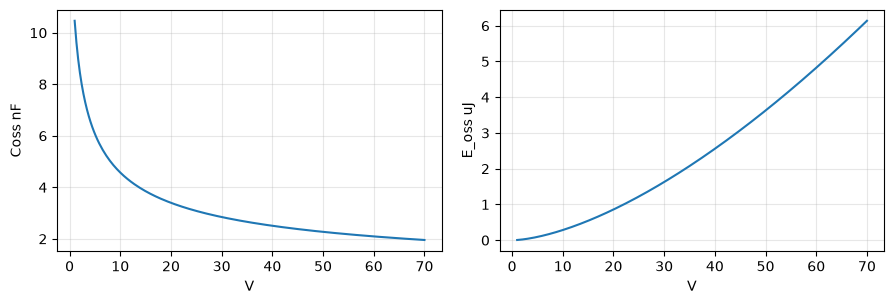

In [10]:
import numpy as np

VDC = (23.0, 33.0, 43.0, 53.0, 63.0)

def e_oss(v, steps=2000):
    grid = np.linspace(0.0, v, steps)
    return np.trapezoid(grid * inverter.coss(grid), grid)

print(' vdc   Coss nF   Qoss nC   E_oss uJ   P_coss W/switch   x6 W')
for vdc in VDC:
    e = e_oss(vdc)
    print('%5.0f   %7.2f   %7.1f   %8.3f   %8.3f   %8.3f'
          % (vdc, inverter.coss(vdc) * 1e9, inverter.qoss(vdc) * 1e9, e * 1e6,
             e * inverter.FSW, 6.0 * e * inverter.FSW))
volts = np.linspace(1.0, 70.0, 200)
fig, (left, right) = figure(rows=1, cols=2)
left.plot(volts, inverter.coss(volts) * 1e9)
left.set_xlabel('V')
left.set_ylabel('Coss nF')
right.plot(volts, [e_oss(v) * 1e6 for v in volts])
right.set_xlabel('V')
right.set_ylabel('E_oss uJ')
show(fig)

## 8 The ring, the blanking margin and the dead-time knee

`ring()` from L_LOOP and Coss, Q_RING assumed 1.0. `blanking()`: the margin for the current sample. `knee_amps` = 2 Qoss / t_dead; `dt_table` is record ids 34-42.

In [11]:
print(' vdc   f_ring MHz   tau ns   settle ns   Z ohm   blanking ns   V_dt V   knee A')
for vdc in VDC:
    r = inverter.ring(vdc)
    print('%5.0f   %9.1f   %6.2f   %8.1f   %6.2f   %10.1f   %6.3f   %6.2f'
          % (vdc, r['f_hz'] / 1e6, r['tau_s'] * 1e9, r['settle_s'] * 1e9, r['z_ohm'],
             inverter.blanking(vdc) * 1e9, inverter.dead_time_volts(vdc), inverter.knee_amps(vdc)))
step, table = inverter.dt_table(43.0)
print('43 V table: step %.2f A, volts %s' % (step, [round(v, 3) for v in table]))
print()
read_ns = check['deadtime_ns']
print('  t_dead ns   which                 V_dt @43 V   knee @43 V   V_dt @63 V   knee @63 V')
for t_dead, which in ((inverter.T_DEAD, 'the record, DTG 8'),
                      (inverter.T_DEAD_SIM, 'the simulation corner'),
                      (read_ns * 1e-9, 'the stage read, DTG %d' % check['deadtime'])):
    print('  %9.1f   %-20s   %8.3f   %8.2f     %8.3f   %8.2f'
          % (t_dead * 1e9, which, inverter.dead_time_volts(43.0, t_dead),
             inverter.knee_amps(43.0, t_dead), inverter.dead_time_volts(63.0, t_dead),
             inverter.knee_amps(63.0, t_dead)))

 vdc   f_ring MHz   tau ns   settle ns   Z ohm   blanking ns   V_dt V   knee A
   23        31.5    10.12       46.6     0.79        143.4    0.039     7.00
   33        34.1     9.34       43.0     0.86        147.0    0.056     8.74
   43        36.1     8.81       40.6     0.91        149.4    0.072    10.27
   53        37.8     8.41       38.8     0.95        151.2    0.089    11.64
   63        39.3     8.10       37.3     0.99        152.7    0.106    12.91
43 V table: step 5.13 A, volts [0.0, 0.033, 0.055, 0.066, 0.07, 0.071, 0.072, 0.072]

  t_dead ns   which                 V_dt @43 V   knee @43 V   V_dt @63 V   knee @63 V
       33.7   the record, DTG 8         0.072      10.27        0.106      12.91
       65.4   the simulation corner      0.141       5.29        0.206       6.65
       79.0   the stage read, DTG 19      0.170       4.38        0.249       5.51


## 9 Conduction, and the measured switching figure

Conduction `I^2 (RDS_ON + SHUNT)`: the shunt's 3.5 mohm binds, not the FET's 1.8. Measured switching: 1.20 W, three legs at 50 % on 24.6 V, half bridge, half supply.

In [12]:
from coaxial.model import thermal

print('  I A   conduction W/phase')
for amps_rms in (1.0, 5.0, 20.0, 50.0, 100.0):
    print('%5.0f   %8.2f' % (amps_rms, amps_rms * amps_rms * (inverter.RDS_ON + inverter.SHUNT)))
bridge = sum(thermal.POWER_SWITCHING[n] for n in thermal.DRIVERS)
whole = sum(thermal.POWER_SWITCHING.values())
coss_w = 6.0 * e_oss(24.6) * inverter.FSW
gate_w = 6.0 * inverter.QG * 12.0 * inverter.FSW
print()
print('camera, three legs 50 %% at 24.6 V: %.2f W switching increment, %.2f W of it on the bridge; '
      'the board as a whole %.2f W in that state' % (2.0 * bridge, bridge, whole))
print('Coss term, six switches at 24.6 V:  %.3f W = %.0f %% of the bridge half'
      % (coss_w, 100.0 * coss_w / bridge))
print('gate charge, 6 x 81 nC x 12 V x FSW: %.3f W at the gates, %.3f W from a buck at 85 %%'
      % (gate_w, gate_w / 0.85))
print('E_oss(63 V) / E_oss(24.6 V) = %.2f, the law the thermal core scales 1.20 W by'
      % (e_oss(63.0) / e_oss(24.6)))

  I A   conduction W/phase
    1       0.01
    5       0.13
   20       2.12
   50      13.25
  100      53.00

camera, three legs 50 % at 24.6 V: 1.20 W switching increment, 0.60 W of it on the bridge; the board as a whole 2.40 W in that state
Coss term, six switches at 24.6 V:  0.357 W = 60 % of the bridge half
gate charge, 6 x 81 nC x 12 V x FSW: 0.292 W at the gates, 0.343 W from a buck at 85 %
E_oss(63 V) / E_oss(24.6 V) = 4.37, the law the thermal core scales 1.20 W by


In [13]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 10 Results

In [14]:
print('1. period       %d ticks = %.1f kHz centre-aligned'
      % (snap['period'], 237.5e6 / (2.0 * (snap['period'] - 1)) / 1e3))
print('   dead time    the stage read DTG %d = %d ns; floor DTG %d = %.1f ns; '
      'the record trims to DTG 8 = %.1f ns'
      % (check['deadtime'], check['deadtime_ns'], check['deadtime_floor'],
         check['deadtime_floor'] * DTS_NS, inverter.T_DEAD * 1e9))
print('2. arming       %d refusals before MOE, in the board\'s words; armed with the break '
      'bypassed and the interlock ignored' % len(refused))
print('3. counted hold %d of %d ticks = %.1f %%, 500 periods = %.3f ms; periods_left %d then %d, '
      'compares %s' % (tenth, snap['period'] - 1, 100.0 * tenth / (snap['period'] - 1),
                       500.0 / 50e3 * 1e3, snap['periods_left'], after['periods_left'],
                       after['duty']))
print('4. snapshots    %d reads, CNT %d to %d of %d; both FETs on in %d of %d leg samples; '
      'gate shorts %s; overruns %d' % (len(snapshots), walked[0], walked[-1], snap['period'],
                                        both_on, 3 * len(snapshots),
                                        snap['gate_shorts'] or 'none', snap['overruns']))
print('5. keepalive    %d edges, worst gap %d cycles = %.1f us'
      % (snap['keepalive'], snap['worst_gap_cycles'], snap['worst_gap_cycles'] / 475.0))
print('6. burst        %d records, dropped %d, %.3f s; %d current columns, %d gate columns; '
      'noise %.2f to %.2f A rms against %s measured'
      % (len(burst), shape['dropped'], df.index[-1], len(amps), len(gates),
         noise.min(), noise.max(), inverter.NOISE_A))
print('7. output charge  Coss %.2f to %.2f nF, E_oss %.2f to %.2f uJ over 23 to 63 V; '
      'six switches %.2f W at 63 V' % (inverter.coss(63.0) * 1e9, inverter.coss(23.0) * 1e9,
                                       e_oss(23.0) * 1e6, e_oss(63.0) * 1e6,
                                       6.0 * e_oss(63.0) * inverter.FSW))
print('8. ring         %.1f to %.1f MHz, settles in %.1f to %.1f ns; blanking margin %.1f ns at 63 V'
      % (inverter.ring(23.0)['f_hz'] / 1e6, inverter.ring(63.0)['f_hz'] / 1e6,
         inverter.ring(63.0)['settle_s'] * 1e9, inverter.ring(23.0)['settle_s'] * 1e9,
         inverter.blanking(63.0) * 1e9))
print('9. dead time    V_dt %.3f V and knee %.2f A at 43 V on the record\'s %.1f ns; '
      '%.3f V and %.2f A on the %d ns the stage read'
      % (inverter.dead_time_volts(43.0), inverter.knee_amps(43.0), inverter.T_DEAD * 1e9,
         inverter.dead_time_volts(43.0, read_ns * 1e-9), inverter.knee_amps(43.0, read_ns * 1e-9),
         read_ns))
print('10. conduction  %.2f W/phase at 20 A, %.2f at 100 A; measured switching %.2f W, '
      'Coss term %.2f W, gate charge %.2f W'
      % (400.0 * (inverter.RDS_ON + inverter.SHUNT), 1e4 * (inverter.RDS_ON + inverter.SHUNT),
         2.0 * bridge, coss_w, gate_w))
print()
print('MEASURED on this board:')
print('   NOISE_A            %s A rms, the phase noise floor' % (inverter.NOISE_A,))
print('   T_DEAD             %.1f ns, DTG 8, trimmed against the supply OCP' % (inverter.T_DEAD * 1e9))
print('   switching          1.20 W, three legs 50 % at 24.6 V, the camera campaign')
print('TRACED from the schematic:')
print('   SHUNT              %.1f mohm, two 7 mohm in parallel' % (inverter.SHUNT * 1e3))
print('   AFE_V_PER_A        %.3f V/A, 4.5455 V/V x the shunt' % inverter.AFE_V_PER_A)
print('FROM THE PART AND THE SIMULATION:')
print('   CJO / M / VJ       %.1f nF / %.2f / %.2f, the VDMOS junction law'
      % (inverter.CJO * 1e9, inverter.M, inverter.VJ))
print('   RDS_ON             %.1f mohm typical, 2.1 max' % (inverter.RDS_ON * 1e3))
print('   AFE_DELAY          %.0f ns, from the AFE simulation' % (inverter.AFE_DELAY * 1e9))
print('ASSUMED:')
print('   Q_RING             %.1f, the ring damping' % inverter.Q_RING)
print('   L_LOOP             %.1f nH, 0.25 nH/mm over the layout' % (inverter.L_LOOP * 1e9))

1. period       2376 ticks = 50.0 kHz centre-aligned
   dead time    the stage read DTG 19 = 79 ns; floor DTG 5 = 21.1 ns; the record trims to DTG 8 = 33.7 ns
2. arming       3 refusals before MOE, in the board's words; armed with the break bypassed and the interlock ignored
3. counted hold 237 of 2375 ticks = 10.0 %, 500 periods = 10.000 ms; periods_left 498 then 0, compares (0, 0, 0)
4. snapshots    12 reads, CNT 276 to 2219 of 2376; both FETs on in 0 of 36 leg samples; gate shorts none; overruns 0
5. keepalive    1498000 edges, worst gap 24700 cycles = 52.0 us
6. burst        300 records, dropped 0, 0.704 s; 3 current columns, 6 gate columns; noise 0.21 to 0.22 A rms against (0.35, 0.41) measured
7. output charge  Coss 2.05 to 3.20 nF, E_oss 1.07 to 5.21 uJ over 23 to 63 V; six switches 1.56 W at 63 V
8. ring         31.5 to 39.3 MHz, settles in 37.3 to 46.6 ns; blanking margin 152.7 ns at 63 V
9. dead time    V_dt 0.072 V and knee 10.27 A at 43 V on the record's 33.7 ns; 0.170 V an

- Dead-time error at 43 V: 0.072 V at DTG 8, 0.170 V at DTG 19; knee 10.3 A vs 4.4 A.
- 500 periods = 10.000 ms; no snapshot in twelve showed both FETs of a leg on.
- Blanking margin at 63 V 152.7 ns - a design figure until TODO 6 measures Q_RING.
- Coss ~60 % of the bridge's 0.6 W; E_oss(63)/E_oss(24.6) ~ V^1.55.

**Bench.** A loaded record answers DTG 8; the drivers need the STO chain's supply. Phase noise after the tare: 0.35-0.41 A rms.

## References

* `host/coaxial/devices/gates.py` - the policy over the stage: `check()`, `interlock()`, `on()`, `off()`
* `host/coaxial/devices/gate_drivers.py` - the board's ops behind `0x6E` device 4: the snapshot, the counted hold, the alternate
* `host/coaxial/model/inverter.py` - the traced constants and the arithmetic on them: `coss`, `ring`, `blanking`, `knee_amps`, `dt_table`
* `host/coaxial/simulated/power.py` - the stand-in this ran on: DTG 19, the walking counter, the counted hold on wall time
* `board/src/board_pwm.c` - TIM1 on the board: MOE, the update ISR's counted hold, the gate short probe
* `docs/HARDWARE.md` - the dead time and its tension, the STO chain, the inverter constants, the loss terms
* `docs/FINDINGS.md` - the OCP trip at 7 counts, the 93 to 108 ms hold, the gate short probe, the camera states
* `host/tests/test_sensorless.py` - the design arithmetic pinned: `coss` and `qoss` consistent, the blanking margin positive over the sweep